In [1]:
import pandas as pd
df = pd.read_csv('ed.csv')

In [2]:
for col in df:
    print(col, f':', df[col].isnull().sum()) 

no : 0
random : 0
age : 0
sex : 0
height : 47
weight : 45
mrs_adm : 0
gcs : 1
hh : 0
sedation_adm : 0
aneurysm_no : 0
aneurysm_trt : 0
infarct_trt : 0
hemorrhage_trt : 0
infarct_dch : 0
rehab_dch : 39
barthel_dch : 37
rehab_barthel_dch : 40
mrs_dch : 0
rehab_score_180 : 46
barthel_180 : 46
rehab_barthel_180 : 46
mrs_180 : 0
gos8_180 : 0
aneurysm_circulation : 0
aneurysm_location : 0
aneurysm_size : 8
hemorrh_before : 0
paresis_adm : 0
aphasia_adm : 0
loc_dch : 0
infection_dch : 0
gos8_dch : 1
dch_imag_modality : 0
shunt_dch : 0
shunt_180 : 0
nimodipine : 0
statin : 0
mg : 0
vs_clin : 0
vs_angio_amount : 65
vs_angio_trt_endo : 0
query_180 : 3
evd_mean : 75
ld_mean : 147
csf_mean : 33
evd_total : 75
ld_total : 147
csf_total : 33
tcd_max : 28
center_size : 0
wfns : 0
ct_ivh : 0
ct_ich : 0
ct_origfisher : 0
ct_modfisher : 0
days_sah_trt : 0
days_sah_trt_ct : 0
days_sah_icu : 0
days_trt_icu : 0
days_sah_ld : 147
days_angio_vs : 65
days_sah_dch : 0
days_sah_dch_imaging : 16
days_sah_death : 

Missing Values by Column:
days_sah_death          243
ld_mean                 147
ld_total                147
days_sah_ld             147
evd_mean                 75
evd_total                75
vs_angio_amount          65
days_angio_vs            65
height                   47
rehab_barthel_180        46
rehab_score_180          46
barthel_180              46
weight                   45
rehab_barthel_dch        40
rehab_dch                39
barthel_dch              37
per_protocol             37
csf_mean                 33
csf_total                33
tcd_max                  28
days_sah_dch_imaging     16
aneurysm_size             8
query_180                 3
gcs                       1
gos8_dch                  1
dtype: int64

% Missing per Column:
no                  0.00
random              0.00
age                 0.00
sex                 0.00
height             16.38
                   ...  
days_trt_ct         0.00
ITT                 0.00
per_protocol       12.89
as_treated   

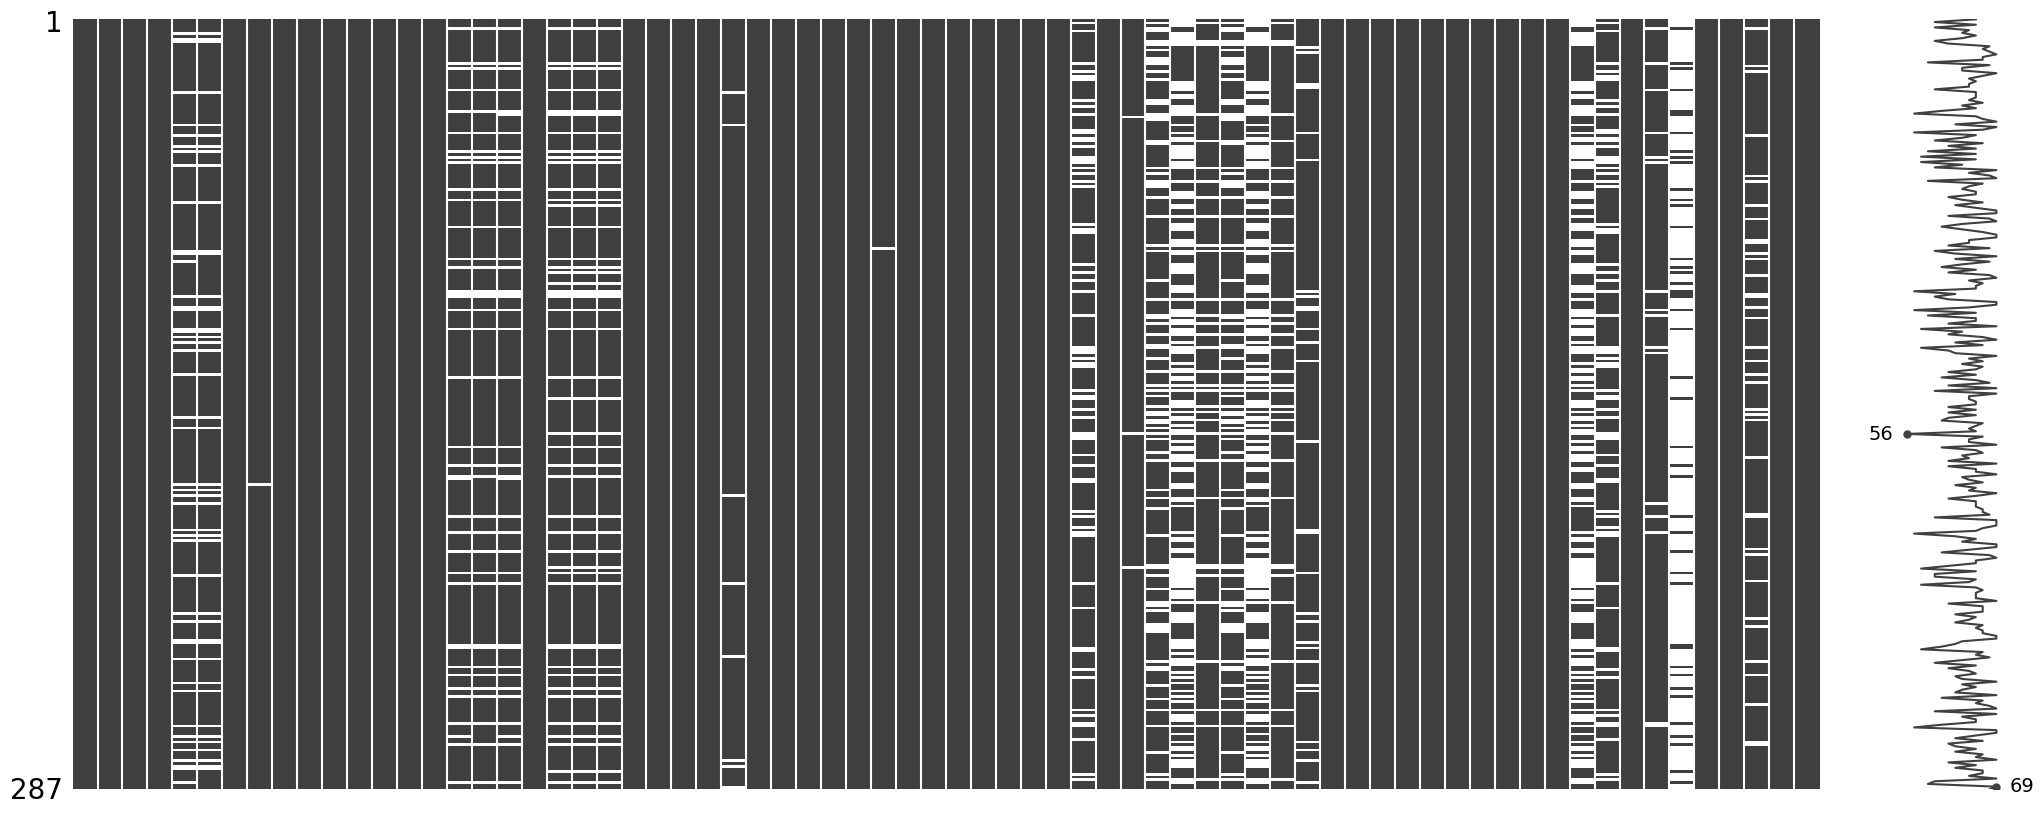

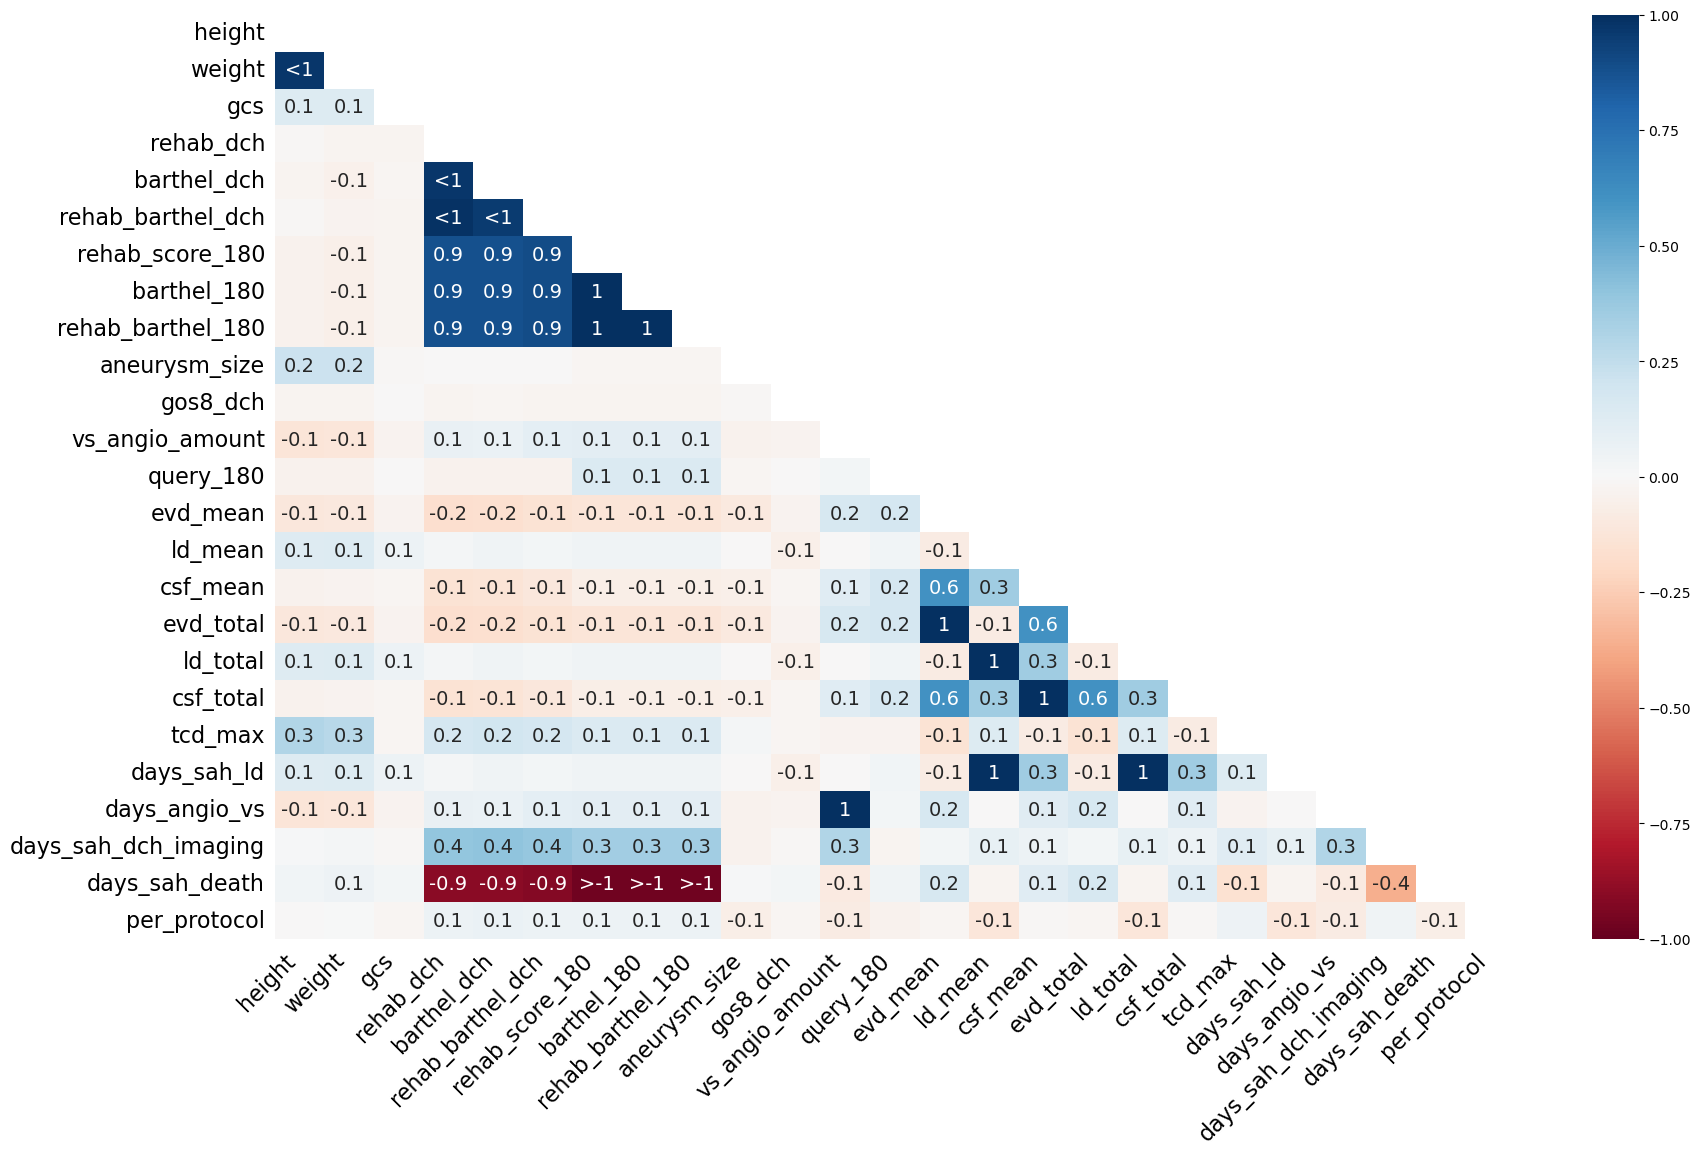

In [8]:
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from scipy import stats

# ========== 1. Load your dataframe ==========
# Assume you already have this:
# df = pd.read_csv("earlydrain.csv")

# ========== 2. Summarize missingness ==========
print("Missing Values by Column:")
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

print("\n% Missing per Column:")
print((df.isnull().mean() * 100).round(2))

print("\nTotal % missing across dataset:", round(df.isnull().stack().mean() * 100, 2), "%")

# Visualize
msno.matrix(df)
msno.heatmap(df)

# ========== 3. Run Little's MCAR Test ==========
from statsmodels.imputation.mice import MICEData

try:
    from statsmodels.imputation.mice import mcar_test
    mcar_test(df)
except:
    print("Little's MCAR test requires only numeric columns. Run this on subset or use alternative tests.")



In [9]:
print("\nTop % Missing per Column:")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(10).round(2))


Top % Missing per Column:
days_sah_death       84.67
ld_mean              51.22
ld_total             51.22
days_sah_ld          51.22
evd_mean             26.13
evd_total            26.13
vs_angio_amount      22.65
days_angio_vs        22.65
height               16.38
rehab_barthel_180    16.03
dtype: float64
